# Практическая работа 2. Часть 2

В ноутбуке исследуется производительность локальных LLM на CPU и GPU, а также влияние размера модели на скорость, потребление ресурсов и качество ответов.

В первом блоке сравнивается запуск `Qwen2.5-1.5B-Instruct` на CPU и GPU, включая стресс-тест с последовательными и параллельными запросами. Во втором блоке сравниваются модели `Qwen2.5` размером **0.5B, 1.5B и 3B** по скорости, VRAM и качеству выполнения одинаковых задач.


## Задание 3. Сравнение CPU и GPU

Одна и та же модель `Qwen2.5-1.5B-Instruct` запускается на CPU и GPU. Сравниваются скорость генерации, использование вычислительных ресурсов и задержка. Дополнительно выполняются 10 последовательных и 5 параллельных запросов для оценки поведения под нагрузкой.

In [1]:
!pip install -q transformers accelerate psutil

In [2]:
import os
import gc
import time
import threading
import statistics

import psutil
import torch

from concurrent.futures import ThreadPoolExecutor
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TextIteratorStreamer,
)

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "Total VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB",
    )

print("CPU cores:", psutil.cpu_count())

CUDA available: True
GPU: Tesla T4
Total VRAM: 14.56 GB
CPU cores: 2


Общие настройки:

In [4]:
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

BENCHMARK_MAX_TOKENS = 150
STRESS_MAX_TOKENS = 50

PROMPT = """
Объясни начинающему ML-инженеру, чем отличается запуск
языковой модели на CPU и GPU. Сравни скорость, требования
к памяти, стоимость оборудования и подходящие сценарии использования.
"""

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Вспомогательная функция для измерения TTFT, времени и tokens/sec:

In [6]:
def generate_streaming(model, device, prompt, max_new_tokens=150):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(device)

    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True,
    )

    generation_kwargs = {
        **inputs,
        "streamer": streamer,
        "max_new_tokens": max_new_tokens,
        "do_sample": False,
    }

    start = time.perf_counter()
    first_token_time = None
    generated_text = ""

    thread = threading.Thread(
        target=model.generate,
        kwargs=generation_kwargs,
    )

    thread.start()

    for text in streamer:
        if text:
            if first_token_time is None:
                first_token_time = time.perf_counter()

            generated_text += text

    thread.join()

    end = time.perf_counter()

    generated_tokens = len(
        tokenizer.encode(
            generated_text,
            add_special_tokens=False,
        )
    )

    total_time = end - start
    ttft = first_token_time - start

    return {
        "ttft": ttft,
        "total_time": total_time,
        "tokens": generated_tokens,
        "tokens_per_sec": generated_tokens / total_time,
        "text": generated_text,
    }

### Эксперимент на CPU

In [7]:
gc.collect()

cpu_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
)

cpu_model.to("cpu")
cpu_model.eval()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

Скорость, загрузка CPU и RAM:

In [8]:
def monitor_cpu(stop_event, samples):
    process = psutil.Process(os.getpid())

    while not stop_event.is_set():
        samples.append({
            "cpu": psutil.cpu_percent(interval=0.1),
            "ram_mb": process.memory_info().rss / 1024**2,
        })

In [9]:
cpu_samples = []
stop_event = threading.Event()

monitor_thread = threading.Thread(
    target=monitor_cpu,
    args=(stop_event, cpu_samples),
)

monitor_thread.start()

cpu_result = generate_streaming(
    cpu_model,
    "cpu",
    PROMPT,
    BENCHMARK_MAX_TOKENS,
)

stop_event.set()
monitor_thread.join()

cpu_avg_load = statistics.mean(x["cpu"] for x in cpu_samples)
cpu_peak_ram = max(x["ram_mb"] for x in cpu_samples)

print("CPU benchmark")
print(f"TTFT: {cpu_result['ttft']:.2f} sec")
print(f"Total time: {cpu_result['total_time']:.2f} sec")
print(f"Speed: {cpu_result['tokens_per_sec']:.2f} tok/s")
print(f"Average CPU load: {cpu_avg_load:.1f}%")
print(f"Peak RAM: {cpu_peak_ram:.0f} MB")

CPU benchmark
TTFT: 4.94 sec
Total time: 84.87 sec
Speed: 1.77 tok/s
Average CPU load: 65.0%
Peak RAM: 7123 MB


Стресс-тест из 10 последовательных запросов:

In [10]:
STRESS_PROMPT = """
Кратко назови три преимущества локального запуска языковой модели.
"""

In [11]:
def sequential_test(model, device):
    times = []

    start_all = time.perf_counter()

    for i in range(10):
        result = generate_streaming(
            model,
            device,
            STRESS_PROMPT,
            STRESS_MAX_TOKENS,
        )

        times.append(result["total_time"])

        print(
            f"{i + 1}: {result['total_time']:.2f} sec"
        )

    total = time.perf_counter() - start_all

    return {
        "avg_latency": statistics.mean(times),
        "total_time": total,
    }

In [12]:
cpu_sequential = sequential_test(cpu_model, "cpu")
cpu_sequential

1: 28.75 sec
2: 28.61 sec
3: 28.47 sec
4: 28.45 sec
5: 28.74 sec
6: 28.79 sec
7: 28.39 sec
8: 28.43 sec
9: 28.43 sec
10: 28.65 sec


{'avg_latency': 28.570946433699998, 'total_time': 285.721298468}

Стресс-тест из 5 параллельных запросов:

In [13]:
def one_request(model, device):
    result = generate_streaming(
        model,
        device,
        STRESS_PROMPT,
        STRESS_MAX_TOKENS,
    )

    return result["total_time"]

In [14]:
def parallel_test(model, device):
    start_all = time.perf_counter()

    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [
            executor.submit(
                one_request,
                model,
                device,
            )
            for _ in range(5)
        ]

        times = [future.result() for future in futures]

    total = time.perf_counter() - start_all

    return {
        "avg_latency": statistics.mean(times),
        "total_time": total,
    }

In [15]:
cpu_parallel = parallel_test(cpu_model, "cpu")
cpu_parallel

{'avg_latency': 131.86009941239996, 'total_time': 132.287658169}

### Эксперимент на GPU

Удаляем CPU-модель и загружаем ту же модель на GPU:

In [16]:
del cpu_model
gc.collect()

172

In [17]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

gpu_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
)

gpu_model.to("cuda")
gpu_model.eval()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

GPU-бенчмарк:

In [18]:
torch.cuda.reset_peak_memory_stats()

gpu_result = generate_streaming(
    gpu_model,
    "cuda",
    PROMPT,
    BENCHMARK_MAX_TOKENS,
)

peak_vram = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

print("GPU benchmark")
print(f"TTFT: {gpu_result['ttft']:.2f} sec")
print(f"Total time: {gpu_result['total_time']:.2f} sec")
print(f"Speed: {gpu_result['tokens_per_sec']:.2f} tok/s")
print(f"Peak VRAM: {peak_vram:.2f} GB")

GPU benchmark
TTFT: 1.91 sec
Total time: 7.68 sec
Speed: 19.52 tok/s
Peak VRAM: 2.90 GB


Стресс-тест модели на GPU:

In [19]:
gpu_sequential = sequential_test(gpu_model, "cuda")
gpu_sequential

1: 2.64 sec
2: 2.04 sec
3: 2.05 sec
4: 1.97 sec
5: 1.97 sec
6: 2.04 sec
7: 2.49 sec
8: 1.96 sec
9: 2.01 sec
10: 1.93 sec


{'avg_latency': 2.109444121100046, 'total_time': 21.105978854000114}

In [20]:
gpu_parallel = parallel_test(gpu_model, "cuda")
gpu_parallel

{'avg_latency': 13.271477857199988, 'total_time': 13.346751385999823}

Итоговая таблица для сравнения:

In [21]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "device": "CPU",
        "tokens_per_sec": cpu_result["tokens_per_sec"],
        "ttft_sec": cpu_result["ttft"],
        "cpu_load_pct": cpu_avg_load,
        "ram_mb": cpu_peak_ram,
        "vram_gb": None,
        "seq_avg_latency_sec": cpu_sequential["avg_latency"],
        "parallel_avg_latency_sec": cpu_parallel["avg_latency"],
    },
    {
        "device": "GPU",
        "tokens_per_sec": gpu_result["tokens_per_sec"],
        "ttft_sec": gpu_result["ttft"],
        "cpu_load_pct": None,
        "ram_mb": None,
        "vram_gb": peak_vram,
        "seq_avg_latency_sec": gpu_sequential["avg_latency"],
        "parallel_avg_latency_sec": gpu_parallel["avg_latency"],
    },
])

comparison

,device,tokens_per_sec,ttft_sec,cpu_load_pct,ram_mb,vram_gb,seq_avg_latency_sec,parallel_avg_latency_sec
0,CPU,1.767439,4.942133,65.035824,7122.839844,NaN,28.570946,131.860099
1,GPU,19.519977,1.912514,NaN,NaN,2.897327,2.109444,13.271478


In [22]:
# "просадка" при параллельной нагрузке

comparison["parallel_latency_increase_pct"] = (
    (
        comparison["parallel_avg_latency_sec"]
        / comparison["seq_avg_latency_sec"]
    ) - 1
) * 100

comparison

,device,tokens_per_sec,ttft_sec,cpu_load_pct,ram_mb,vram_gb,seq_avg_latency_sec,parallel_avg_latency_sec,parallel_latency_increase_pct
0,CPU,1.767439,4.942133,65.035824,7122.839844,NaN,28.570946,131.860099,361.518136
1,GPU,19.519977,1.912514,NaN,NaN,2.897327,2.109444,13.271478,529.145741


### Анализ результатов

GPU оказался значительно быстрее CPU. Скорость генерации выросла с **1.77 tok/s** на CPU до **19.52 tok/s** на GPU — примерно в **11 раз**. TTFT сократился с **4.94 с** до **1.91 с**.

При одиночной последовательной нагрузке средняя задержка составила **28.57 с** на CPU и **2.11 с** на GPU. При 5 параллельных запросах задержка выросла до **131.86 с** на CPU и **13.27 с** на GPU. Относительная просадка при параллельной нагрузке составила около **362%** для CPU и **529%** для GPU, однако в абсолютных значениях GPU всё равно оставался примерно в 10 раз быстрее.

Во время CPU-inference средняя загрузка процессора составила **65%**, пиковое потребление RAM — около **7.1 GB**. На GPU пиковое использование VRAM составило около **2.9 GB**.

### Вывод

GPU оправдан, когда важны низкая задержка, высокая скорость генерации или одновременная обработка нескольких запросов. В данном эксперименте GPU обеспечил примерно **11-кратный прирост скорости** и существенно меньшую задержку даже под параллельной нагрузкой.

CPU может быть достаточен для редких запросов, небольших моделей и сценариев, где скорость не критична. Для интерактивных и нагруженных LLM-сервисов использование GPU значительно эффективнее.


## Задание 4. Сравнение моделей разного размера

Сравниваются три модели семейства Qwen2.5-Instruct размером 0.5B, 1.5B и 3B параметров.  
Все модели запускаются на одном GPU в FP16. Для каждой модели измеряются время загрузки, потребление RAM/VRAM и скорость генерации, после чего сравнивается качество ответов на одинаковых задачах.

In [1]:
!pip install -q transformers accelerate psutil

In [2]:
import os
import gc
import time
import psutil
import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM

In [3]:
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Total VRAM:",
    round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
    "GB",
)

CUDA available: True
GPU: Tesla T4
Total VRAM: 14.56 GB


Модели:

In [4]:
MODELS = {
    "0.5B": "Qwen/Qwen2.5-0.5B-Instruct",
    "1.5B": "Qwen/Qwen2.5-1.5B-Instruct",
    "3B": "Qwen/Qwen2.5-3B-Instruct",
}

MODEL_SIZES = {
    "0.5B": 0.5,
    "1.5B": 1.5,
    "3B": 3.0,
}

Задания:

In [5]:
LOGIC_PROMPT = """
У Маши, Олега и Иры разные профессии:
врач, программист и учитель.

Известно:
- Маша не врач.
- Олег не программист.
- Ира не учитель.
- Олег не врач.

Определи профессию каждого и кратко объясни рассуждение.
"""

MATH_PROMPT = """
В магазине товар сначала подорожал на 20%,
а затем новая цена была снижена на 20%.

После этих изменений товар стоит 960 рублей.

Сколько рублей товар стоил первоначально?
Покажи вычисления и объясни ответ.
"""

CODE_PROMPT = """
Напиши функцию Python:

def second_largest_unique(values):

Функция принимает список целых чисел и возвращает
второе по величине уникальное значение.

Если уникальных значений меньше двух, функция должна вернуть None.

Примеры:
second_largest_unique([5, 1, 5, 3, 2]) -> 3
second_largest_unique([4, 4]) -> None

Добавь краткое объяснение решения.
"""

EXPLANATION_PROMPT = """
Объясни начинающему ML-инженеру,
почему attention в Transformer позволяет учитывать
связи между удалёнными друг от друга словами.

Объясни роль query, key и value,
а также зачем используется scaled dot-product attention.

Ответ должен быть технически точным, но понятным.
"""

Загрузка модели и измерение ресурсов:

In [6]:
def get_ram_gb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**3

In [7]:
def load_model(model_id):
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    ram_before = get_ram_gb()

    start = time.perf_counter()

    tokenizer = AutoTokenizer.from_pretrained(model_id)

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    )

    model.to("cuda")
    model.eval()

    torch.cuda.synchronize()

    load_time = time.perf_counter() - start

    ram_after = get_ram_gb()

    vram_after = (
        torch.cuda.memory_allocated()
        / 1024**3
    )

    return model, tokenizer, {
        "load_time_sec": load_time,
        "ram_gb": ram_after,
        "ram_increase_gb": ram_after - ram_before,
        "vram_gb": vram_after,
    }

Генерация ответов и измерение метрик:

In [8]:
def generate_and_measure(
    model,
    tokenizer,
    prompt,
    max_new_tokens=250,
):
    messages = [
        {
            "role": "user",
            "content": prompt,
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(text, return_tensors="pt").to("cuda")

    input_tokens = inputs["input_ids"].shape[1]

    torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
        )

    torch.cuda.synchronize()
    total_time = time.perf_counter() - start

    generated_ids = output[0][input_tokens:]

    generated_tokens = len(generated_ids)

    answer = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    )

    tokens_per_sec = generated_tokens / total_time

    peak_vram_gb = (
        torch.cuda.max_memory_allocated()
        / 1024**3
    )

    return {
        "time_sec": total_time,
        "tokens": generated_tokens,
        "tokens_per_sec": tokens_per_sec,
        "peak_vram_gb": peak_vram_gb,
        "answer": answer,
    }

Для скорости используем отдельный промпт:

In [9]:
SPEED_PROMPT = """
Объясни основные преимущества и недостатки
локального запуска языковых моделей по сравнению
с использованием облачного API.
"""

Последовательно загружаем модели:

In [10]:
results = {}

for size_name, model_id in MODELS.items():

    print("\n" + "=" * 70)
    print(size_name, model_id)
    print("=" * 70)

    model, tokenizer, load_stats = load_model(model_id)

    print(f"Load time: {load_stats['load_time_sec']:.2f} sec")
    print(f"RAM: {load_stats['ram_gb']:.2f} GB")
    print(f"RAM increase: {load_stats['ram_increase_gb']:.2f} GB")
    print(f"VRAM after load: {load_stats['vram_gb']:.2f} GB")

    # Основной benchmark скорости
    torch.cuda.reset_peak_memory_stats()

    speed_result = generate_and_measure(
        model,
        tokenizer,
        SPEED_PROMPT,
        max_new_tokens=200,
    )

    print(f"Speed: {speed_result['tokens_per_sec']:.2f} tok/s")
    print(f"Peak VRAM: {speed_result['peak_vram_gb']:.2f} GB")

    # Качественные задания
    logic_result = generate_and_measure(
        model,
        tokenizer,
        LOGIC_PROMPT,
        max_new_tokens=400,
    )

    math_result = generate_and_measure(
        model,
        tokenizer,
        MATH_PROMPT,
        max_new_tokens=400,
    )

    code_result = generate_and_measure(
        model,
        tokenizer,
        CODE_PROMPT,
        max_new_tokens=700,
    )

    explanation_result = generate_and_measure(
        model,
        tokenizer,
        EXPLANATION_PROMPT,
        max_new_tokens=700,
    )

    results[size_name] = {
        "model_id": model_id,
        "load": load_stats,
        "speed": speed_result,
        "logic": logic_result,
        "math": math_result,
        "code": code_result,
        "explanation": explanation_result,
    }

    # Полностью удаляем модель
    del model
    del tokenizer

    gc.collect()
    torch.cuda.empty_cache()


0.5B Qwen/Qwen2.5-0.5B-Instruct


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Load time: 182.32 sec
RAM: 3.74 GB
RAM increase: -0.85 GB
VRAM after load: 5.86 GB
Speed: 19.09 tok/s
Peak VRAM: 5.88 GB


Итоговая таблица производительности:

In [11]:
rows = []

for size_name, r in results.items():
    rows.append({
        "model": size_name,
        "parameters_billion": MODEL_SIZES[size_name],
        "load_time_sec": r["load"]["load_time_sec"],
        "ram_gb": r["load"]["ram_gb"],
        "ram_increase_gb": r["load"]["ram_increase_gb"],
        "peak_vram_gb": r["speed"]["peak_vram_gb"],
        "tokens_per_sec": r["speed"]["tokens_per_sec"],
    })

metrics_df = pd.DataFrame(rows)

metrics_df

,model,parameters_billion,load_time_sec,ram_gb,ram_increase_gb,peak_vram_gb,tokens_per_sec
0,0.5B,0.5,21.669715,1.739422,0.871437,0.943979,12.532454
1,1.5B,1.5,48.117332,4.672710,2.307320,2.899107,24.011168
2,3B,3.0,182.324961,3.741890,-0.847290,5.879858,19.094896


Зависимость размера от скорости:

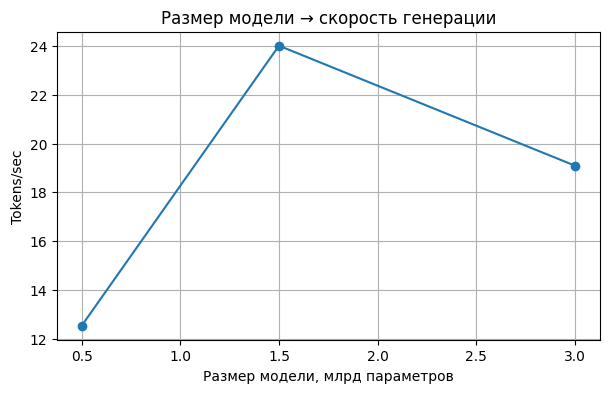

In [12]:
plt.figure(figsize=(7, 4))

plt.plot(
    metrics_df["parameters_billion"],
    metrics_df["tokens_per_sec"],
    marker="o",
)

plt.xlabel("Размер модели, млрд параметров")
plt.ylabel("Tokens/sec")
plt.title("Размер модели → скорость генерации")
plt.grid(True)

plt.show()

Зависимость размера от VRAM:

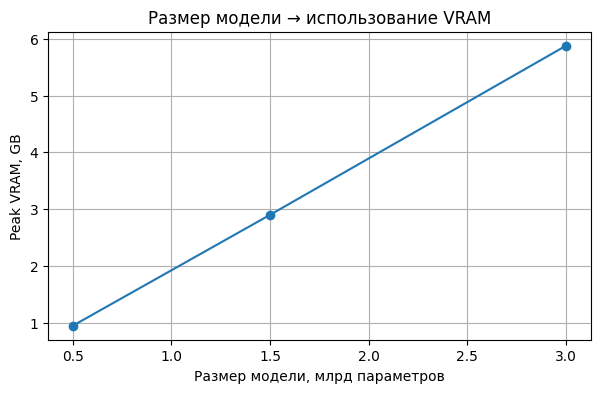

In [13]:
plt.figure(figsize=(7, 4))

plt.plot(
    metrics_df["parameters_billion"],
    metrics_df["peak_vram_gb"],
    marker="o",
)

plt.xlabel("Размер модели, млрд параметров")
plt.ylabel("Peak VRAM, GB")
plt.title("Размер модели → использование VRAM")
plt.grid(True)

plt.show()

Вывод ответов для ручной проверки качества:

In [14]:
for size_name, r in results.items():

    print("\n" + "=" * 80)
    print(size_name)
    print("=" * 80)

    print("\nLOGIC:")
    print(r["logic"]["answer"])

    print("\nMATH:")
    print(r["math"]["answer"])

    print("\nCODE:")
    print(r["code"]["answer"])

    print("\nEXPLANATION:")
    print(r["explanation"]["answer"])


0.5B

LOGIC:
Вот рассуждение по этому вопросу:

1. Маша не врач: Это значит, Маша не является врачом.

2. Олег не программист: Это значит, Олег не является программистом.

3. Ира не учитель: Это значит, Ира не является ученым.

4. Олег не врач: Это значит, Олег не является врачом.

Таким образом, мы можем предположить следующую профессию для каждого человека:

- Маша - ученик (из-за описания "ученый" в прошлом)
- Олег - учитель (из-за описания "ученик" в прошлом)
- Ира - ученик (из-за описания "ученый" в прошлом)

Это рассуждение основано на следующих основных фактах:

1. Маша не врач — значит, она не врач.
2. Олег не программист — значит, он не программист.
3. Ира не учитель — значит, она не учитель.
4. Олег не врач — значит, он не врач.

Поскольку все эти условия совпадают с прошлыми профессиями, можно сделать вывод, что Маша, Олег и Ира являются учениками или учеными.

MATH:
Давайте решим эту задачу шаг за шагом:

1) Предположим, что первое降价 было 20%, то есть:
   \( 960 \times 0.2

Критерии оценки (максимум 8 баллов для каждой модели):

| Балл | Значение                                       |
| ---: | ---------------------------------------------- |
|    0 | неправильный ответ                             |
|    1 | частично правильный / есть существенные ошибки |
|    2 | правильный и качественный ответ                |


Оценка качества:

| Модель | Логика | Математика | Код | Объяснение |    Итог |
| ------ | -----: | ---------: | --: | ---------: | ------: |
| 0.5B   |      0 |          0 |   0 |          1 | **1/8** |
| 1.5B   |      1 |          2 |   2 |          1 | **6/8** |
| 3B     |      0 |          1 |   2 |          2 | **5/8** |


У 0.5B ошибки есть почти во всех задачах: неверно решены логика и математика, а код не соответствует условию. 1.5B корректно решила математику и задачу на код, но логический ответ не был доведён до решения. 3B дала наиболее содержательное объяснение attention и правильный код, но неожиданно ошиблась в логической задаче; в математике правильный ответ соседствует с противоречием в финальном объяснении.

### Анализ результатов

С увеличением размера модели заметно растёт потребление GPU-памяти: с **0.94 GB** для 0.5B до **2.90 GB** для 1.5B и **5.88 GB** для 3B. Время загрузки также выросло с **21.67 с** до **48.12 с** и **182.32 с** соответственно.

Скорость генерации не зависела от размера модели монотонно. Максимальную скорость показала модель 1.5B — **24.01 tok/s**, затем 3B — **19.09 tok/s**, а 0.5B — **12.53 tok/s**. Следовательно, на GPU количество параметров является не единственным фактором производительности.

По качеству модель 0.5B заметно уступила более крупным вариантам. Переход к 1.5B дал существенное улучшение в математике и генерации кода. Модель 3B дала наиболее подробное и технически содержательное объяснение сложной темы, однако не показала стабильного преимущества во всех заданиях и допустила ошибку в логической задаче.

### Вывод

Рост модели с **0.5B до 1.5B в данном эксперименте оправдан**: качество заметно увеличилось при умеренном росте требований к ресурсам. Переход с **1.5B до 3B** уже не дал однозначного улучшения качества, при этом потребление VRAM выросло примерно вдвое, а время загрузки — почти в четыре раза.

Таким образом, увеличение размера модели само по себе не гарантирует пропорционального роста качества. Оптимальный размер следует выбирать по результатам тестирования на целевых задачах с учётом доступных вычислительных ресурсов.
